CRISPR dataset columns: Index(['A1BG (1)', 'A1CF (29974)', 'A2M (2)', 'A2ML1 (144568)',
       'A3GALT2 (127550)', 'A4GALT (53947)', 'A4GNT (51146)', 'AAAS (8086)',
       'AACS (65985)', 'AADAC (13)',
       ...
       'ZWILCH (55055)', 'ZWINT (11130)', 'ZXDA (7789)', 'ZXDB (158586)',
       'ZXDC (79364)', 'ZYG11A (440590)', 'ZYG11B (79699)', 'ZYX (7791)',
       'ZZEF1 (23140)', 'ZZZ3 (26009)'],
      dtype='object', length=17916)
Converted cell lines: {'PIK3CA': ['ACH-002180', 'ACH-000824', 'ACH-001414', 'ACH-000442', 'ACH-000547', 'ACH-001411', 'ACH-000593', 'ACH-001331', 'ACH-001336', 'ACH-001442', 'ACH-001864', 'ACH-000808', 'ACH-000028', 'ACH-001061', 'ACH-000546', 'ACH-001359'], 'KDM6A': ['ACH-000879', 'ACH-001669', 'ACH-000270', 'ACH-000473', 'ACH-001183', 'ACH-001199', 'ACH-002155', 'ACH-002238', 'ACH-001098', 'ACH-002216'], 'ARID1A': ['ACH-001765', 'ACH-000982', 'ACH-000957', 'ACH-000943', 'ACH-001060', 'ACH-000247', 'ACH-000985', 'ACH-000939', 'ACH-000720', 'ACH-000946', '

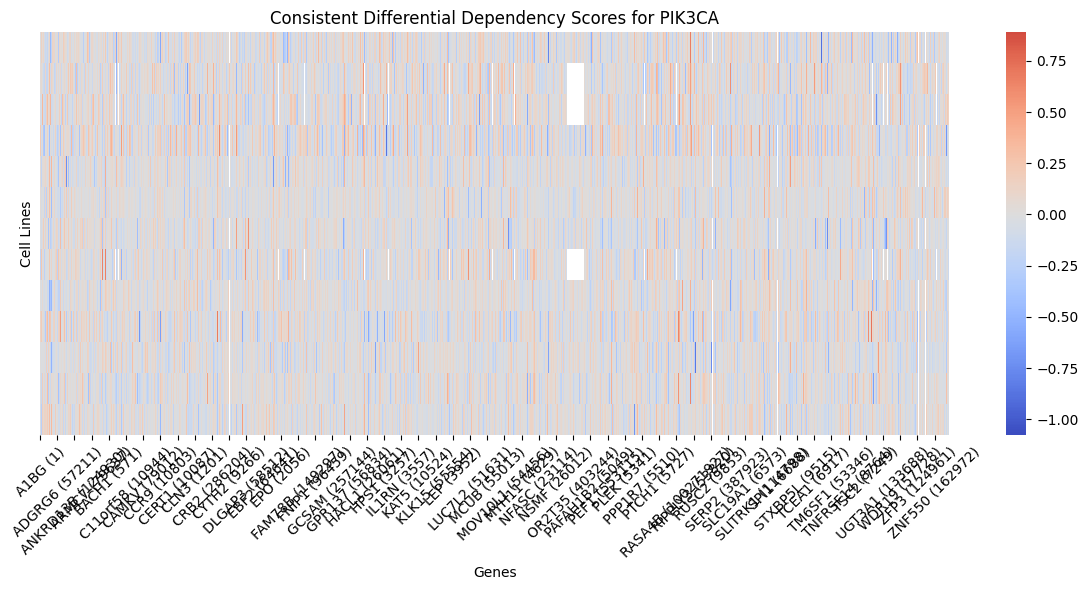

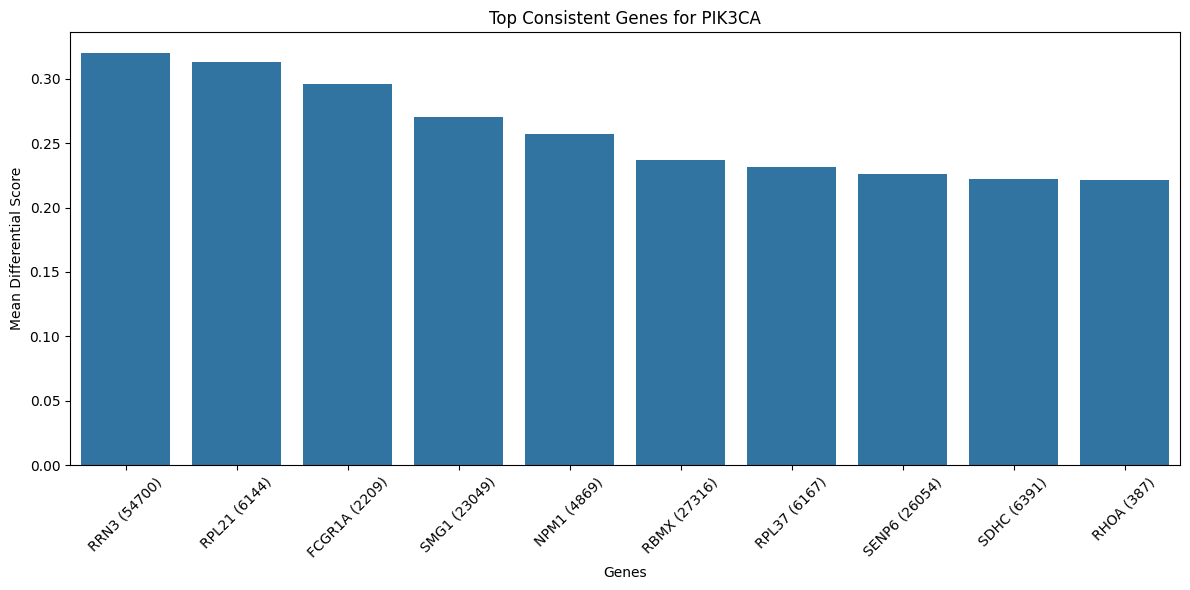

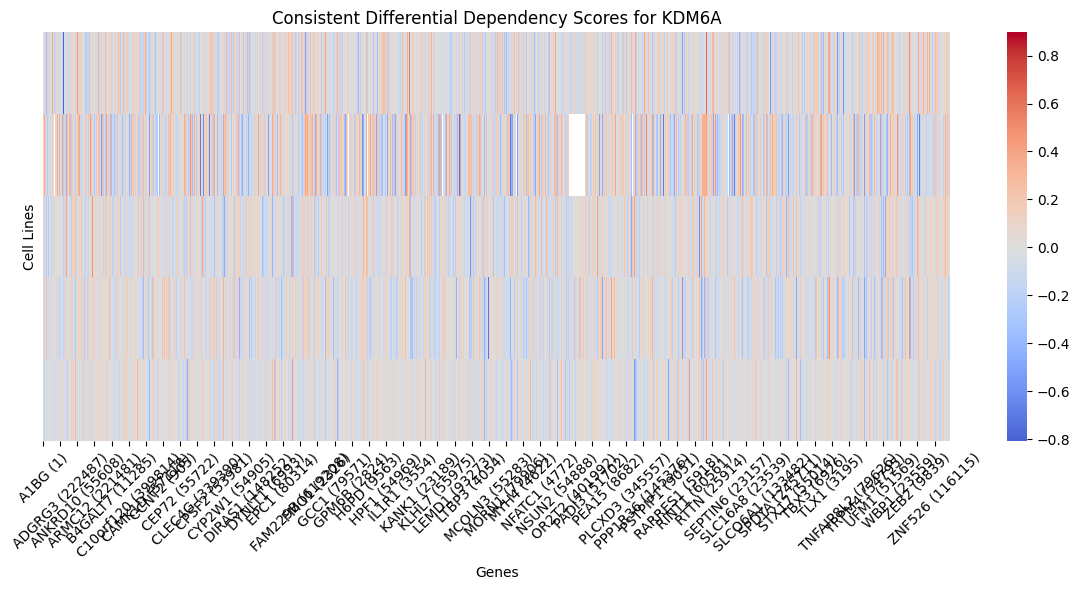

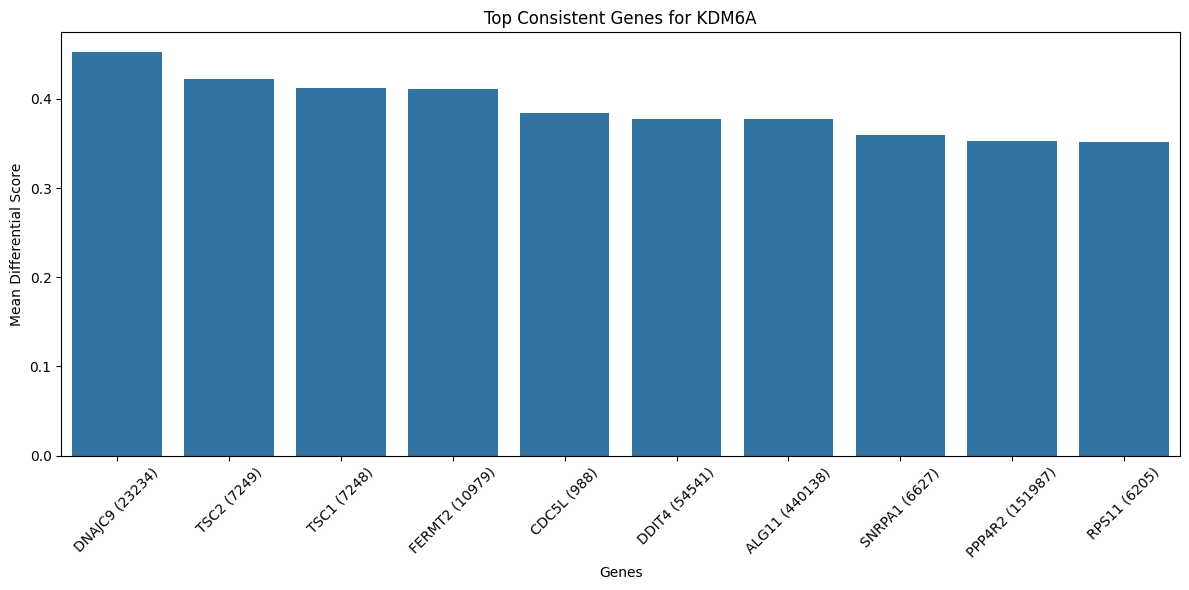

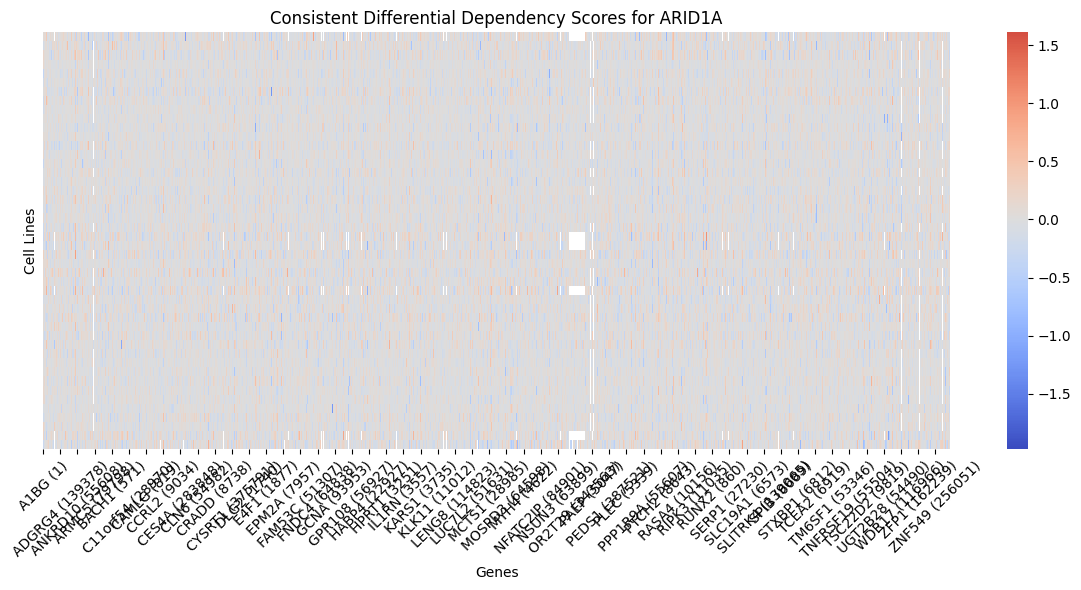

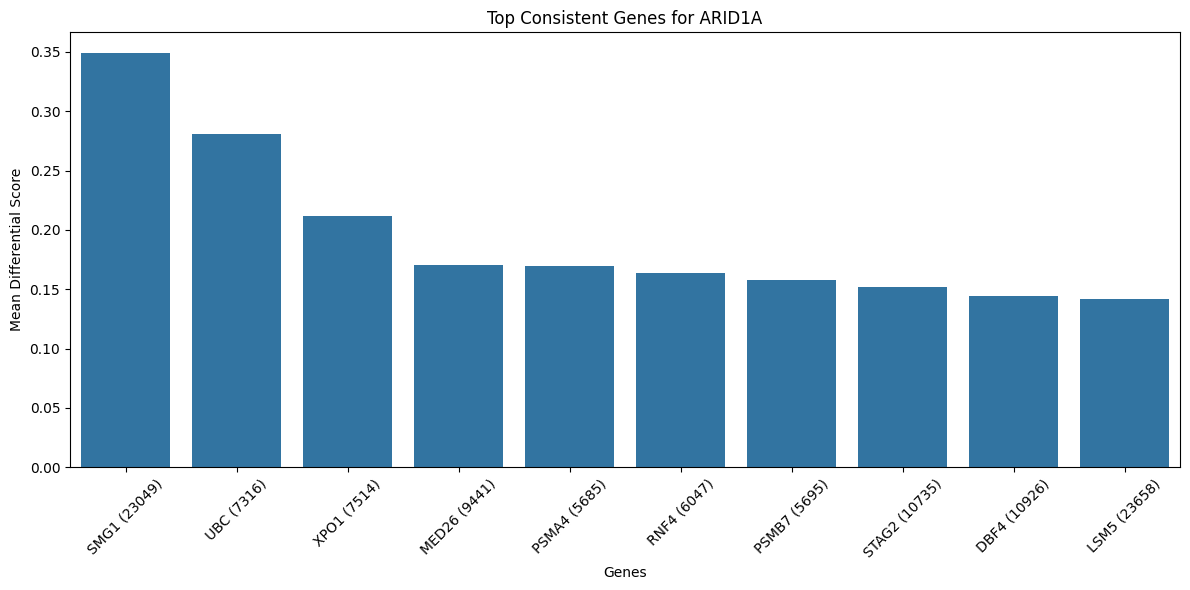

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the CRISPR dependency dataset and make cell lines the index
crispr_df = pd.read_csv('CRISPRGeneEffect.csv', low_memory=False, index_col=0)
print("CRISPR dataset columns:", crispr_df.columns)

# Load the mapping file (models.csv) to convert cell line names to ACH notation
models_df = pd.read_csv('Model.csv')

# Create a dictionary to map cell line names (e.g., OMC1) to ACH notation (e.g., ACH-002180)
cell_line_mapping = dict(zip(models_df['StrippedCellLineName'], models_df['ModelID']))

# Define the cell line lists for PIK3CA, KDM6A, and ARID1A mutations
cell_lines = {
    "PIK3CA": [
        'OMC1', 'KYSE510', 'UMUC6', 'RERFLCSQ1', 'HT1197', 'UMUC5', 'BC3C',
        'BICR10', 'CASKI', 'A388', 'YSCCC', 'HUH28', 'KPL1', 'DLD1', 'HSC4', 'ME180'
    ],
    "KDM6A": [
        'MFE296', 'TANOUE', 'HPAC', 'RT112', 'RT11284', 'SNUC2B', 'LB996RCC',
        'GRST', 'KCIMOH1', 'BE13'
    ],
    "ARID1A": [
        'RH4', 'GP2D', 'LS180', 'RKO', 'DL40', 'OCUM1', 'LS411N', 'SKUT1',
        'TCCSUP', 'HEC265', 'P31FUJ', 'SNU1', 'SW48', 'KYSE450', 'NCIH2172', 
        'A2780', 'MFE319', 'OS186', 'RKO', 'CAL51', 'SNU349', 'VACO432', 
        'AN3CA', 'HHUA', 'SNGM', 'NCIH838', 'AN3CA', 'NCIH460', 'LOVO', 
        'VACO432', 'ISHIKAWAHERAKLIO02ER', 'HHUA', 'SNGM', 'KARPAS422', 
        'UMUC10', 'PACADD165', 'HEC151', 'L1236', 'GA10', 'NY', 'ES4', 
        'CP67MEL', 'C33A', 'SNUC5', 'OCILY19', 'SNU638', 'NCIH128', 
        'KKU055', 'KMCH1', 'GP5D', 'HEC108', 'PACADD137', 'EN', 'JHUEM2', 
        'ES1', 'MFM223', 'MN60', 'SKLU1', 'OC316', 'OC314', 'JURKAT', 
        'SNU1040', 'HEC6', 'OCIC5X', 'HEC116', 'DV90', 'OCIC5X', 'SNU324', 
        'HEC59', 'OVTOKO'
    ]
}

# Convert cell line names to ACH notation
converted_cell_lines = {
    mutation: [cell_line_mapping[cell] for cell in cell_list if cell in cell_line_mapping]
    for mutation, cell_list in cell_lines.items()
}
print("Converted cell lines:", converted_cell_lines)

# Process each mutation
results = {}
for mutation, cell_line_list in converted_cell_lines.items():
    # Filter cell lines positive for the mutation
    positive_df = crispr_df[crispr_df.index.isin(cell_line_list)]
    
    # Filter negative cell lines (complement)
    negative_df = crispr_df[~crispr_df.index.isin(cell_line_list)]
    
    # Calculate mean differential dependency scores
    differential_scores = positive_df - negative_df.mean(axis=0)
    mean_scores = differential_scores.mean(axis=0)
    
    # Filter for consistency (low standard deviation)
    consistency_threshold = differential_scores.std(axis=0).mean() / 0.4
    consistent_genes = differential_scores.columns[differential_scores.std(axis=0) < consistency_threshold]
    
    consistent_scores = differential_scores[consistent_genes]
    mean_consistent_scores = consistent_scores.mean(axis=0)
    sorted_consistent_scores = mean_consistent_scores.sort_values()
    results[mutation] = sorted_consistent_scores

    # Visualize heatmap of consistent genes
    plt.figure(figsize=(12, 6))
    sns.heatmap(consistent_scores, annot=False, cmap='coolwarm', center=0, yticklabels=False)
    plt.title(f'Consistent Differential Dependency Scores for {mutation}')
    plt.xlabel('Genes')
    plt.ylabel('Cell Lines')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Bar plot of top consistent genes
    plt.figure(figsize=(12, 6))
    top_genes = mean_consistent_scores.nlargest(10)
    sns.barplot(x=top_genes.index, y=top_genes.values)
    plt.title(f'Top Consistent Genes for {mutation}')
    plt.xlabel('Genes')
    plt.ylabel('Mean Differential Score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Save the results
for mutation, scores in results.items():
    scores.to_csv(f'{mutation}_consistent_genes.csv', header=True)